In [ ]:
# 数据处理常用库
import pandas as pd
# 基因签名处理模块
from ctxcore.genesig import GeneSignature
# pyscenic AUCcell 相关函数（用于基因集富集分析）
from pyscenic.aucell import create_rankings, enrichment
from pyscenic.aucell import aucell, derive_auc_threshold, create_rankings

# 操作系统路径与随机种子模块
import os
import random
# 类型注释工具
from typing import Dict, List, Optional, Tuple

# 数值计算与数组操作
import numpy as np
import pandas as pd  # 这里再次导入不会造成错误，仅为方便使用 DataFrame

# 单细胞数据分析、绘图与准确度评估
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, classification_report, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
# Omicverse 生态体系
import omicverse as ov
# Scanpy 已导入；再次导入不会出错，但非必要
import scanpy as sc
import scvelo as scv

# 设置 Omicverse 绘图主题集
ov.plot_set()

/root/autodl-tmp/tools/envs/ModuCell/lib/python3.10/site-packages/ctxcore/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/root/autodl-tmp/tools/envs/ModuCell/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 4090
    • Total memory: 23.5 GB
    • Compute capability: 8.9

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [ ]:
# 读取训练集和测试集 AnnData 文件
ad1 = sc.read_h5ad('./data_train_5.h5ad')  # 训练数据
ad2 = sc.read_h5ad('./data_test_5.h5ad')   # 测试数据

# 合并两个 AnnData 对象，按细胞（行）拼接
merged = sc.concat([ad1, ad2], axis=0, join='outer', merge='same')  # join='outer' 保留所有基因，merge='same' 同名基因处理

# 将表达矩阵转为 float32，避免深度复制提升效率
arr = merged.X.astype('float32', copy=False)

# 转为 CSC 稀疏矩阵格式，可以加快稀疏计算
from scipy import sparse
csc = sparse.csc_matrix(arr)

# 赋值回 AnnData
merged.X = csc
# 输出 merged.X 以便交互式查看（可能在 notebook 里打印）
merged.X

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 55644200 stored elements and shape (16382, 19093)>

normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:19)


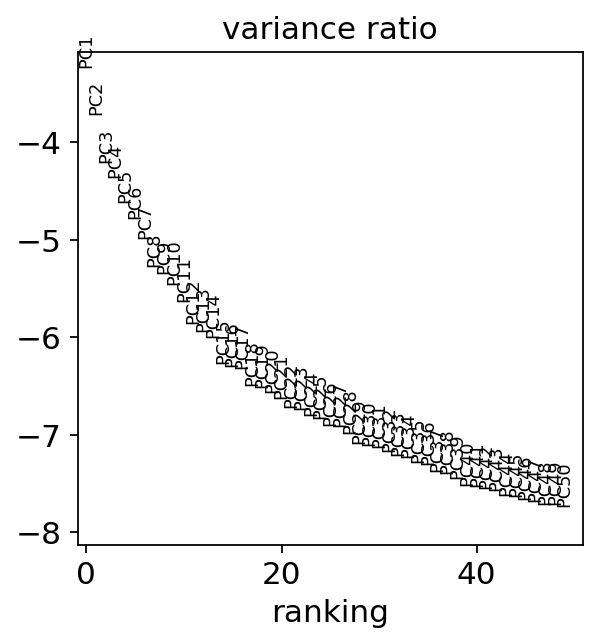

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:34)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:13)
running Leiden clustering
    finished: found 37 clusters and added
    'leiden_res1', the cluster labels (adata.obs, categorical) (0:00:06)


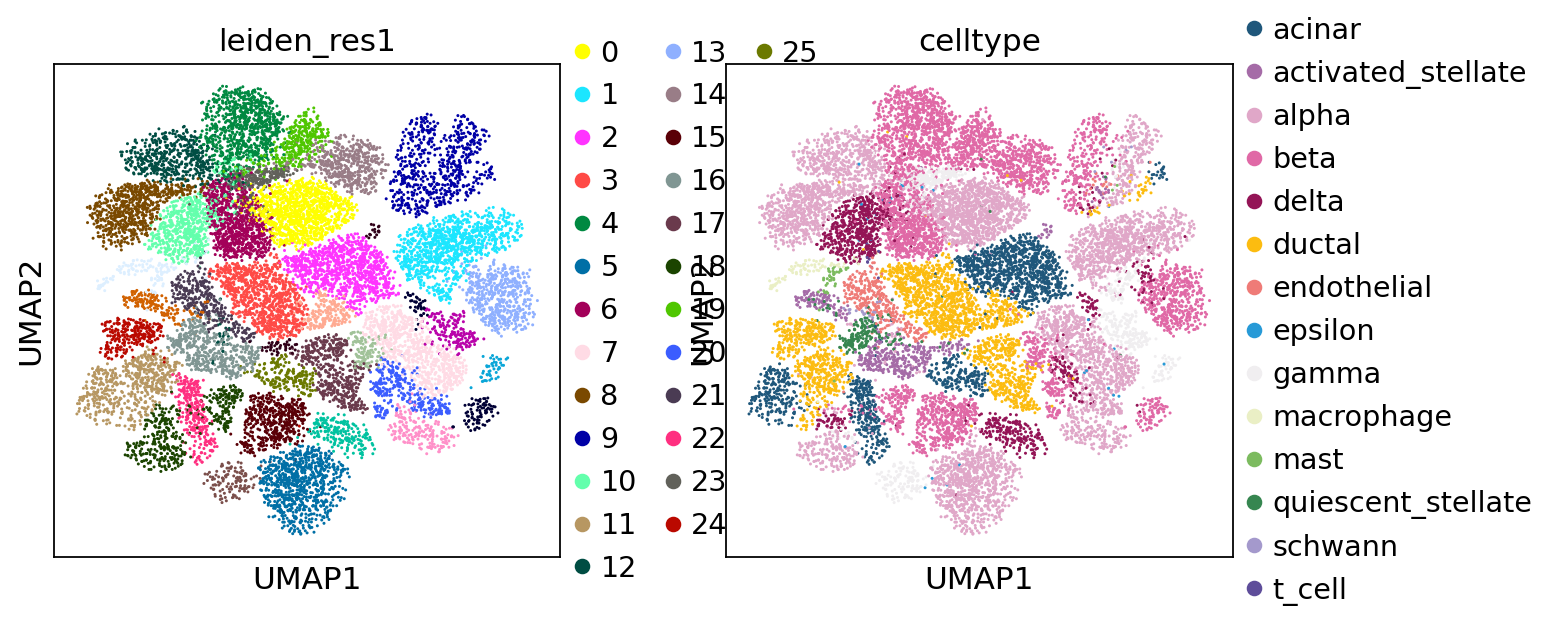

In [ ]:
# 确保变量名唯一，避免因重名基因引起下游索引问题
merged.var_names_make_unique()

# 归一化每个细胞的总表达量，使总数为 1e4
sc.pp.normalize_total(merged, target_sum=1e4)
# 对数转换，减少高表达基因对距离计算的影响
sc.pp.log1p(merged)

# 将预处理前的数据保存到 merged.raw 中，供后续可恢复原始值
merged.raw = merged

# 按最大值截断，避免极端值对 PCA/聚类产生过大影响
sc.pp.scale(merged, max_value=10)

# PCA 计算降维，50 维足以用于大多数单细胞数据分析
sc.pp.pca(merged)
# 绘制主成分方差贡献比，验证主成分数是否合理
sc.pl.pca_variance_ratio(merged, n_pcs=50, log=True)

# 构建邻接图，用于 UMAP、聚类等下游分析
sc.pp.neighbors(merged, n_neighbors=20, n_pcs=50)
# 计算 UMAP 二维坐标，用于可视化
sc.tl.umap(merged, min_dist=2)

# Leiden 聚类，生成细胞亚群标签
sc.tl.leiden(merged, resolution=0.5, flavor="leidenalg", key_added="leiden_res1")
# 绘制 UMAP，按聚类和已知细胞类型着色，并保存图片
sc.pl.umap(merged, color=["leiden_res1", "celltype"], save='_.png')

In [ ]:
# 从 GMT 文件读取模块基因集定义
pathway_dict = ov.utils.geneset_prepare('./edge_explainer_results_lou2/louvain_modules.gmt')

# 转换为 raw 数据用于富集计算（保留原始未归一化表达）
adata_raw = merged.raw.to_adata()

# 执行 AUCcell 差异表达之路富集分析
adata_aucs = ov.single.pathway_aucell_enrichment(
    adata_raw,
    pathways_dict=pathway_dict,
    num_workers=8
)

# 为了保持原始索引、观测和空间矩阵与 merged 对齐，覆盖 obs、obsm、obsp
adata_aucs.obs = adata_raw[merged.obs.index].obs
adata_aucs.obsm = adata_raw[merged.obs.index].obsm
adata_aucs.obsp = adata_raw[merged.obs.index].obsp

# 可选绘图代码，已注释掉用于调试或后续加速
# ov.pl.dotplot(
#     adata_aucs, marker_genes_dict,
#     groupby='celltype', cmap='RdBu_r',
#     standard_scale='var'
# )

ctxcore have been install version: 0.2.0


100%|██████████| 16382/16382 [00:15<00:00, 1053.52it/s]


Computing AUC scores for 63 pathways using 8 workers...
Splitting 63 pathways into 8 chunks of ~8 pathways each...
Starting parallel pathway processing...


/root/autodl-tmp/tools/envs/ModuCell/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/root/autodl-tmp/tools/envs/ModuCell/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/root/autodl-tmp/tools/envs/ModuCell/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import py

Parallel processing completed!
AUC calculation completed! Generated scores for 63 pathways across 16382 cells.


NameError: name 'marker_genes_dict' is not defined

In [ ]:
# 查看所有 pathway 特征（变量）名称
list(adata_aucs.var_names)

['acinar__module1',
 'acinar__module2',
 'acinar__module3',
 'acinar__module4',
 'activated_stellate__module1',
 'activated_stellate__module2',
 'activated_stellate__module3',
 'activated_stellate__module4',
 'alpha__module1',
 'alpha__module2',
 'alpha__module3',
 'alpha__module4',
 'alpha__module5',
 'beta__module1',
 'beta__module2',
 'beta__module3',
 'beta__module4',
 'beta__module5',
 'beta__module6',
 'delta__module1',
 'delta__module2',
 'delta__module3',
 'delta__module4',
 'ductal__module1',
 'ductal__module2',
 'ductal__module3',
 'ductal__module4',
 'endothelial__module1',
 'endothelial__module2',
 'endothelial__module3',
 'endothelial__module4',
 'endothelial__module5',
 'endothelial__module6',
 'epsilon__module1',
 'epsilon__module2',
 'epsilon__module3',
 'epsilon__module4',
 'epsilon__module5',
 'gamma__module1',
 'gamma__module2',
 'gamma__module3',
 'gamma__module4',
 'gamma__module5',
 'macrophage__module1',
 'macrophage__module2',
 'macrophage__module3',
 'mast__mod

In [ ]:
# 正则和字典工具
import re
from collections import defaultdict, OrderedDict

# 1. 准备 names 列表
names = list(adata_aucs.var_names)  # 或 adata_aucs.var_names.tolist()

# 2. 用正则按尾部 "_数字" 提取前缀（可包含下划线）
pattern = re.compile(r'^(.*)_\d+$')  # 捕获结尾为下划线+数字之前的所有内容

# group key 为前缀，value 为原始完整名称列表
groups = defaultdict(list)
for n in names:
    m = pattern.match(n)
    if m:
        key = m.group(1)  # 提取前缀
    else:
        # 若不匹配（例如没有尾部数字），则以整个名字为 key
        key = n
    groups[key].append(n)

# 3. 获取目标顺序：adata_aucs.obs['celltype'] 的 categories（若存在）
if 'celltype' in adata_aucs.obs.columns:
    ct = adata_aucs.obs['celltype']
    if hasattr(ct, 'cat'):
        # 如果 celltype 是分类类型，直接读取类别顺序
        categories = list(ct.cat.categories)
    else:
        # 否则手动保持出现顺序去重
        seen = set()
        categories = []
        for v in ct.tolist():
            if v not in seen:
                seen.add(v)
                categories.append(v)
else:
    raise KeyError("adata_aucs.obs 中未找到 'celltype' 列，请检查列名是否正确。")

# 4. 按 categories 顺序重建字典（只包含存在于 groups 的键）
marker_genes_dict_ordered = OrderedDict()
for k in categories:
    if k in groups:
        marker_genes_dict_ordered[k] = groups[k]

# 5. （可选）只保留每组前 N 个成员
N = None  # 若想限制数量，例如 N = 3；若不限制则保留全部（设为 None）
if N is not None:
    marker_genes_dict_ordered = OrderedDict((k, v[:N]) for k, v in marker_genes_dict_ordered.items())

# 6. 转为普通 dict 来保持兼容性
marker_genes_dict = dict(marker_genes_dict_ordered)
marker_genes_dict

{}

In [ ]:
# 正则和字典工具
import re
from collections import defaultdict, OrderedDict

# 1. 准备 names 列表
names = list(adata_aucs.var_names)  # 或 adata_aucs.var_names.tolist()

# 2. 用正则按尾部 "__module数字" 提取前缀
pattern = re.compile(r'^(.*)__module\d+$')  # 捕获结尾为 __module+数字之前的所有内容

groups = defaultdict(list)
for n in names:
    m = pattern.match(n)
    if m:
        key = m.group(1)
    else:
        # 若不匹配（例如没有 __module数字 后缀），则以整个名字为 key
        key = n
    groups[key].append(n)

# 3. 获取目标顺序：adata_aucs.obs['celltype'] 的 categories（若存在）
if 'celltype' in adata_aucs.obs.columns:
    ct = adata_aucs.obs['celltype']
    if hasattr(ct, 'cat'):
        categories = list(ct.cat.categories)
    else:
        seen = set()
        categories = []
        for v in ct.tolist():
            if v not in seen:
                seen.add(v)
                categories.append(v)
else:
    raise KeyError("adata_aucs.obs 中未找到 'celltype' 列，请检查列名是否正确。")

# 4. 按 categories 顺序重建字典（只包含存在于 groups 的键）
marker_genes_dict_ordered = OrderedDict()
for k in categories:
    if k in groups:
        marker_genes_dict_ordered[k] = groups[k]

# 5. （可选）只保留每组前 N 个成员
N = None  # 若想限制数量，例如 N = 3；若不限制则保留全部（设为 None）
if N is not None:
    marker_genes_dict_ordered = OrderedDict((k, v[:N]) for k, v in marker_genes_dict_ordered.items())

# 6. 如需转为普通 dict（Python 3.7+ 保持插入顺序）
marker_genes_dict = dict(marker_genes_dict_ordered)

# 配置图形输出格式以确保与 Illustrator 兼容
import matplotlib as mpl
import hashlib
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# 绘制 dotplot 并保存
ov.pl.dotplot(
    adata_aucs, marker_genes_dict,
    groupby='celltype', cmap='RdBu_r',
    standard_scale='var'
)
# 保存当前 figure
plt.savefig("./dotplot_final.pdf", dpi=300, bbox_inches="tight")
plt.close()

In [13]:
# 保存当前 figure
plt.savefig("./dotplot_final.pdf", dpi=300, bbox_inches="tight")
plt.close()